# Modeling Forgetting with Artificial Neurons

## Model 1: Passive Memory Decay

We begin by modeling a memory as an association with strength 'w'.

We assume that memory strength decays at a rate proportional to its current strength:

dw/dt = -ƛw

Solving the differential equation gives:

w(t) = w₀e^(-ƛt)

where:
- w₀ is the initial memory strength
- ƛ is the decay rate
- t is the elapsed time
- w: [0, 1]

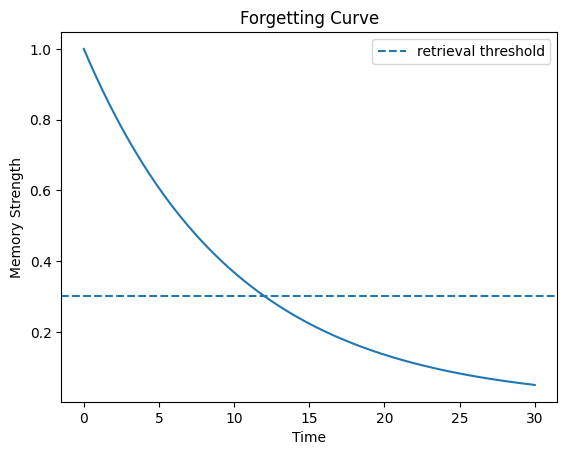

In [13]:
import numpy as np
import matplotlib.pyplot as plt

w0 = 1.0
decay_rate = 0.1
retrieval_threshold = 0.3

time = np.linspace(0, 30, 300)  # Time from 0 to 30 seconds, with 300 points

memory_strength = w0 * np.exp(-decay_rate * time)

retrieved = memory_strength >= retrieval_threshold

plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='retrieval threshold')

plt.xlabel("Time")
plt.ylabel("Memory Strength")
plt.title("Forgetting Curve")
plt.legend()

plt.show()





## Model 2: Memory Reinforcement

The baseline model assumes that a memory passively decays over time. However, memories can be strengthened through review or retrieval.

To model reinforcement, a review at time t increases the synaptic weight according to:

w_new = w + ⍺(1 - w)

where ⍺ is the learning rate. The term (1 - w) represents the remaining capacity for the memory to strengthen, preventing the weight from exceeding 1.

Between reviews, the memory continues to decay exponentially.

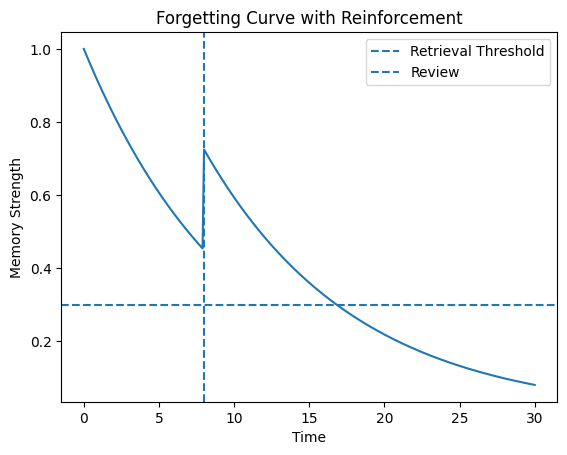

In [14]:
review_time = 8
learning_rate = 0.5

time = np.linspace(0, 30, 301)
dt = time[1]-time[0]

memory_strength = np.zeros(len(time))
memory_strength[0] = 1.0  # Initial memory strength

for i in range(1, len(time)):
    memory_strength[i] = memory_strength[i-1] * np.exp(-decay_rate * dt)

    if time[i-1] < review_time <= time[i]:
        memory_strength[i] = memory_strength[i] + learning_rate * (1 - memory_strength[i])

plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='Retrieval Threshold')
plt.axvline(x=review_time, linestyle='--', label='Review')

plt.xlabel('Time')
plt.ylabel('Memory Strength')
plt.title('Forgetting Curve with Reinforcement')
plt.legend()

plt.show()



## Model 3: Spaced Repetition

Now, we'd like to model how our memory strength over time if we utilize spaced repitition, meaning we reinforce the memory in discrete time steps.

We predict that the memory will stay above the retrieval threshold, meaning we're able to recall it, for a longer amount of time.

We are utilizing the same equations and assumptions as above, where the memory continues to decay exponentially between each memory reinforcement.

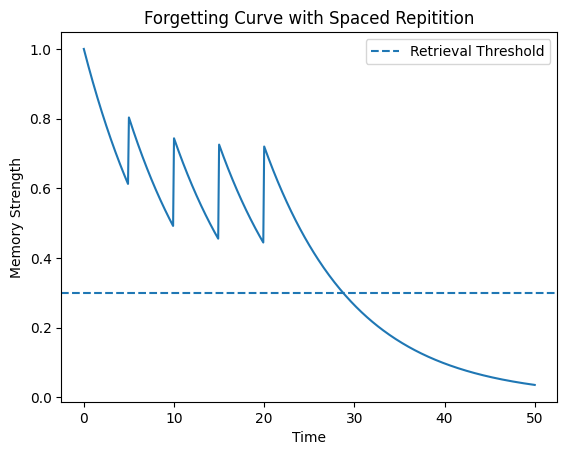

In [15]:
learning_rate = 0.5
review_time_start = 5
review_time_end = 20
time_step = 5
review_time = review_time_start

time = np.linspace(0, 50, 501)
dt = time[1]-time[0]

memory_strength = np.zeros(len(time))
memory_strength[0] = 1.0

for i in range(1, len(time)):
    memory_strength[i] = memory_strength[i-1] * np.exp(-decay_rate * dt)

    if time[i-1] < review_time <= time[i]:
        memory_strength[i] = memory_strength[i] + learning_rate * (1 - memory_strength[i])
        if review_time_start <= review_time < review_time_end:
            review_time += time_step

plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='Retrieval Threshold')

plt.xlabel('Time')
plt.ylabel('Memory Strength')
plt.title('Forgetting Curve with Spaced Repitition')
plt.legend()

plt.show()


### Interpretation of Model 3

As seen by the graph above, spaced repetition allows for the memory strength to stay above the retrieval threshold for longer.

Next, we'll explore the question: What if successful reinforcement doesn't merely increase w, but also makes the memory decay more slowly afterward?